# 5.1 — Alignment and Characterization of the X-ray Beam

**Virtual lab:** *Ultrafast X-Ray Experiments* (Exp21), FXE @ European XFEL.
**Goal of this notebook:** work exercises 1–9, i.e. choose the incident X-ray
energy for a non-resonant Fe K$\beta_{1,3}$ emission experiment and characterise
the beam delivered on the optical bench (size, position, jitter, spectrum,
attenuation and focusing).

**On data.** Every cell runs out-of-the-box on physically-motivated *synthetic*
stand-ins so the analysis can be prepared before beamtime. To use real VLab
exports instead, drop the corresponding files into `data/` (see the loader
calls — each states the expected filename) and re-run; the loaders prefer a
real file whenever it is present. If you can open the online app
(https://play.unity.com/en/games/3e3b50d5-b027-473c-adc2-d606c5030baa/xfel-virtual-lab),
export the screenshots/traces it produces into `data/` with those names.

X-ray optical constants come from `xraydb` (the same tabulation as the CXRO
database referenced in the script), so no network access is required.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Run from the repository root and import `vlab_xray` from this repository's
# own `src/`, so that `data/` and `figures/` resolve identically no matter
# where Jupyter was started and an editable install of another copy of the
# package cannot shadow these sources.
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "src" / "vlab_xray").is_dir())
os.chdir(ROOT)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from vlab_xray import vlab_utils as V

V.use_paper_style()
os.makedirs("figures", exist_ok=True)
print("Fe K-edge (script value / xraydb):", V.FE_K_EDGE_EV, "/", V.edge_energy("Fe", "K"), "eV")

Fe K-edge (script value / xraydb): 7112.0 / 7112.0 eV


## Exercise 1 — Choice of the nominal undulator energy $E_0$

For **non-resonant** Fe K$\beta$ emission the 1s core electron must be promoted
into the continuum, not into bound valence levels. Two constraints fix $E_0$:

1. it must lie **above the Fe K-edge** (7112 eV), so the 1s shell is ionised;
2. it should sit **beyond the XANES/near-edge and first EXAFS region**
   (a few tens of eV above the edge) so that the excitation probability does
   not carry the energy-dependent fine structure of bound/scattering
   resonances — otherwise the *incident* spectrum would modulate the recorded
   emission.

A pragmatic choice is $E_0 \approx 7250$ eV: safely above the edge and past the
strong near-edge features, while the K$\beta$ emission lines themselves sit near
7045–7060 eV and are unaffected by the exact $E_0$.

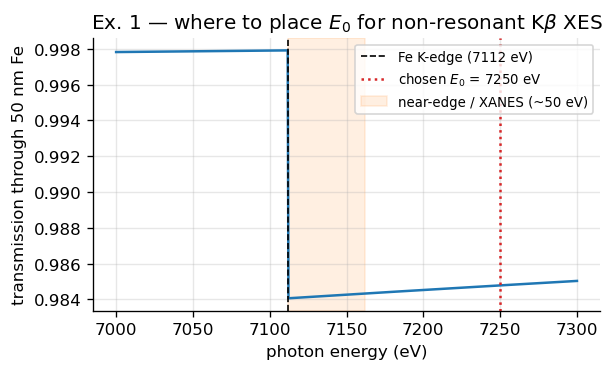

Absorption jump at the K-edge is clearly visible; E0 = 7250 eV lies 138 eV above it, past the near-edge region.


In [2]:
E0 = 7250.0  # chosen nominal undulator energy [eV]

# transmission through a thin Fe layer from below the edge up to E0
E = np.linspace(7000, 7300, 600)
T_fe = V.transmission("Fe", E, thickness_cm=50e-7)  # 50 nm Fe reference layer

fig, ax = plt.subplots(figsize=(5.2, 3.2))
ax.plot(E, T_fe)
ax.axvline(V.FE_K_EDGE_EV, color="k", ls="--", lw=1, label="Fe K-edge (7112 eV)")
ax.axvline(E0, color="C3", ls=":", lw=1.5, label=f"chosen $E_0$ = {E0:.0f} eV")
ax.axvspan(V.FE_K_EDGE_EV, V.FE_K_EDGE_EV + 50, color="C1", alpha=0.12,
           label="near-edge / XANES (~50 eV)")
ax.set_xlabel("photon energy (eV)")
ax.set_ylabel("transmission through 50 nm Fe")
ax.set_title("Ex. 1 — where to place $E_0$ for non-resonant K$\\beta$ XES")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig("figures/ex01_E0_choice.png", dpi=150)
plt.show()

edge_drop = 1 - V.transmission("Fe", V.FE_K_EDGE_EV + 1, 50e-7) / \
    V.transmission("Fe", V.FE_K_EDGE_EV - 1, 50e-7)
print(f"Absorption jump at the K-edge is clearly visible; "
      f"E0 = {E0:.0f} eV lies {E0 - V.FE_K_EDGE_EV:.0f} eV above it, past the near-edge region.")

**Result.** $E_0 = 7250$ eV — above the K-edge (a), beyond the XANES/first-EXAFS
region (b). The transmission curve shows the characteristic absorption jump at
7112 eV; at $E_0$ the cross-section is back on the smooth $\propto E^{-3}$ decay,
which is exactly the featureless continuum wanted for non-resonant XES.

## Exercise 2 — Beam size, position and pulse-to-pulse jitter on BIU2

Confirm a beam on the beam-imaging unit BIU2, then quantify it:
horizontal/vertical profiles and their FWHM, and — from ~20 single-pulse
images — the mean centroid and its standard deviation (the spatial jitter).

*Data:* save the single-pulse frames as one stack `data/biu2_stack.npy`,
shape `(N, ny, nx)` (a single 2-D image is accepted too and treated as a
stack of one). Absent that, a synthetic stack
with realistic jitter is used (horizontal ≈ one beam diameter, vertical ≈ 10×
smaller, cf. Sec. 6.2.2).

BIU2 stack: (20, 120, 160) | source: synthetic


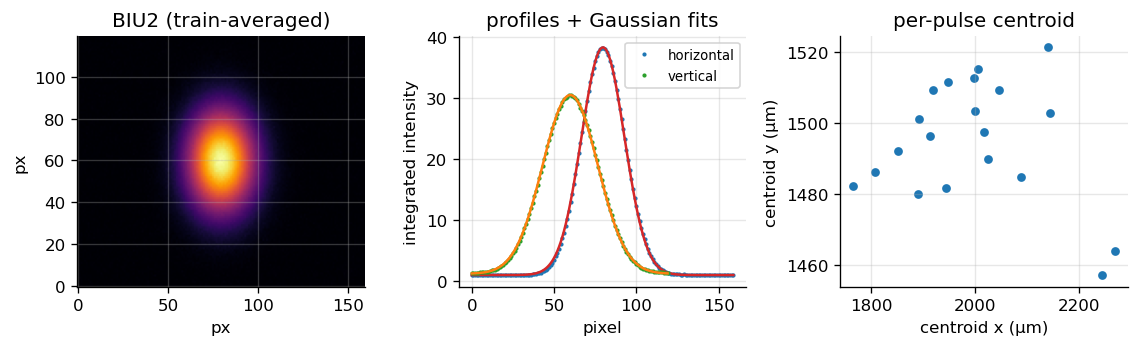

Beam FWHM:  H =  769.2 µm   V =  989.5 µm
Mean position (px): x = 79.82, y = 59.80
Jitter (±1 SD):  H = 133.6 µm   V =  16.9 µm


In [3]:
stack, src = V.load_image("biu2_stack", gen=lambda: V.Synthetic.biu2_stack(n=20))
if stack.ndim == 2:           # a single saved image -> wrap into a length-1 stack
    stack = stack[None]
print("BIU2 stack:", stack.shape, "| source:", src or "synthetic")

# work on the pulse-train average for the profile/FWHM (a BIU integrates a train)
avg = stack.mean(axis=0)
col_prof, row_prof = V.profiles(avg)
xpx = np.arange(avg.shape[1]); ypx = np.arange(avg.shape[0])
fit_h = V.fit_gaussian(xpx, col_prof)
fit_v = V.fit_gaussian(ypx, row_prof)

# per-pulse centroid -> jitter
cx = np.array([V.centroid_2d(im)[0] for im in stack])
cy = np.array([V.centroid_2d(im)[1] for im in stack])

PIX_UM = 25.0   # BIU optical resolution ~25 um/pixel (Sec. 6.4.1)
fig, axs = plt.subplots(1, 3, figsize=(9.6, 3.0))
axs[0].imshow(avg, origin="lower", cmap="inferno", aspect="auto")
axs[0].set_title("BIU2 (train-averaged)"); axs[0].set_xlabel("px"); axs[0].set_ylabel("px")
axs[1].plot(xpx, col_prof, ".", ms=3, label="horizontal")
axs[1].plot(xpx, V.gaussian(xpx, fit_h["amp"], fit_h["cen"], fit_h["sigma"], fit_h["offset"]), "C3")
axs[1].plot(ypx, row_prof, ".", ms=3, label="vertical", color="C2")
axs[1].plot(ypx, V.gaussian(ypx, fit_v["amp"], fit_v["cen"], fit_v["sigma"], fit_v["offset"]), "C1")
axs[1].set_xlabel("pixel"); axs[1].set_ylabel("integrated intensity"); axs[1].legend(fontsize=8)
axs[1].set_title("profiles + Gaussian fits")
axs[2].scatter(cx * PIX_UM, cy * PIX_UM, s=18)
axs[2].set_xlabel("centroid x (µm)"); axs[2].set_ylabel("centroid y (µm)")
axs[2].set_title("per-pulse centroid")
fig.tight_layout(); fig.savefig("figures/ex02_biu2.png", dpi=150); plt.show()

print(f"Beam FWHM:  H = {fit_h['fwhm']*PIX_UM:6.1f} µm   V = {fit_v['fwhm']*PIX_UM:6.1f} µm")
print(f"Mean position (px): x = {cx.mean():.2f}, y = {cy.mean():.2f}")
print(f"Jitter (±1 SD):  H = {cx.std(ddof=1)*PIX_UM:5.1f} µm   "
      f"V = {cy.std(ddof=1)*PIX_UM:5.1f} µm")

**Result / discussion.** The horizontal jitter is several times the vertical one,
consistent with the M1–M3 mirror pointing instability discussed in Sec. 6.2.2.
Whether the experiment is feasible depends on the ratio *jitter / beam size*:
if the pointing SD is a sizeable fraction of the FWHM, the pump–probe overlap
fluctuates shot to shot and the transient signal is diluted. This motivates
**focusing** (Ex. 9), which shrinks the jitter, and using the IPM (Ex. 7) to
normalise/sort shots.

## Exercise 3 — Pink vs. monochromatic beam on BIU2

Inserting the four-bounce Si(111) monochromator cuts the SASE bandwidth from
$\Delta E/E\sim10^{-3}$ (pink) to $\sim10^{-4}$ (mono), at a large cost in flux.
Compare the two beams on BIU2 (intensity and profile).

*Data:* `data/biu2_pink.npy`, `data/biu2_mono.npy`.

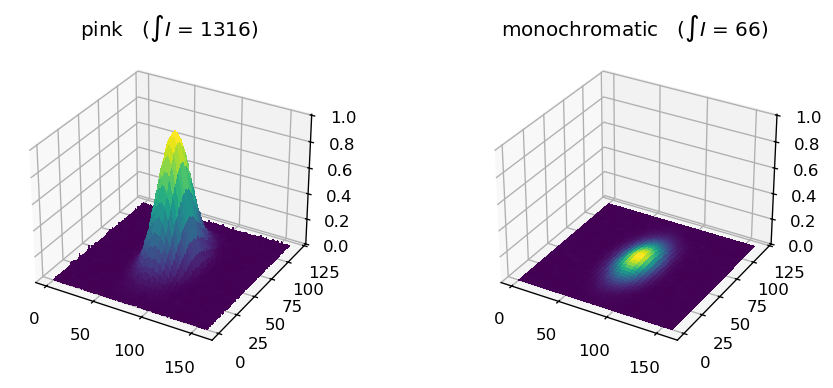

Integrated-intensity ratio mono/pink ≈ 5.01e-02 (monochromatisation throws away most of the flux).


In [4]:
pink, src_pink = V.load_image("biu2_pink", gen=lambda: V.Synthetic.beam_image(noise=0.01, seed=1))
mono_scale = 0.05  # illustrative flux fraction transmitted by the 4-bounce mono
mono_img, src_mono = V.load_image("biu2_mono",
                                  gen=lambda: mono_scale * V.Synthetic.beam_image(noise=0.01, seed=2))
# A session may hold only one of the two frames. Comparing a measured image
# against a synthetic stand-in would give a flux ratio off by whatever
# arbitrary scale the generator happens to use, so say so instead.
comparable = (src_pink is None) == (src_mono is None)

fig = plt.figure(figsize=(8.4, 3.2))
for i, (img, name) in enumerate([(pink, "pink"), (mono_img, "monochromatic")]):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    ys, xs = np.indices(img.shape)
    ax.plot_surface(xs, ys, img, cmap="viridis", linewidth=0, antialiased=False)
    ax.set_title(fr"{name}   ($\int I$ = {img.sum():.0f})")
    ax.set_zlim(0, max(pink.max(), 1e-6))
fig.tight_layout(); fig.savefig("figures/ex03_pink_vs_mono.png", dpi=150); plt.show()
if comparable:
    print(f"Integrated-intensity ratio mono/pink ≈ {mono_img.sum()/pink.sum():.2e} "
          f"(monochromatisation throws away most of the flux).")
else:
    print(f"pink: {src_pink or 'synthetic'}\nmono: {src_mono or 'synthetic'}")
    print("Only one of the two frames is measured, so their intensity ratio is "
          "meaningless.\nCompare the pink and mono flux on SpA1 in Ex. 6 instead.")

**Result.** The profile shape is essentially unchanged; the intensity drops by
more than an order of magnitude because the Si(111) reflection accepts only a
narrow slice of the SASE bandwidth. Quantify the bandwidths in Ex. 4/5.

## Exercise 4 — SASE (pink) spectrum with the single-shot analyser SpA1

Plot three single-shot spectra and the many-shot average; read off the FWHM
bandwidth of the pink beam and compare with the EuXFEL example (Fig. 6.15):
single shots are spiky (~100 SASE modes), the average is smooth with
$\Delta E/E\sim10^{-3}$.

*Data:* `data/spa1_pink_shot0.txt` … and `data/spa1_pink_avg.txt` (2 columns:
energy [eV], intensity).

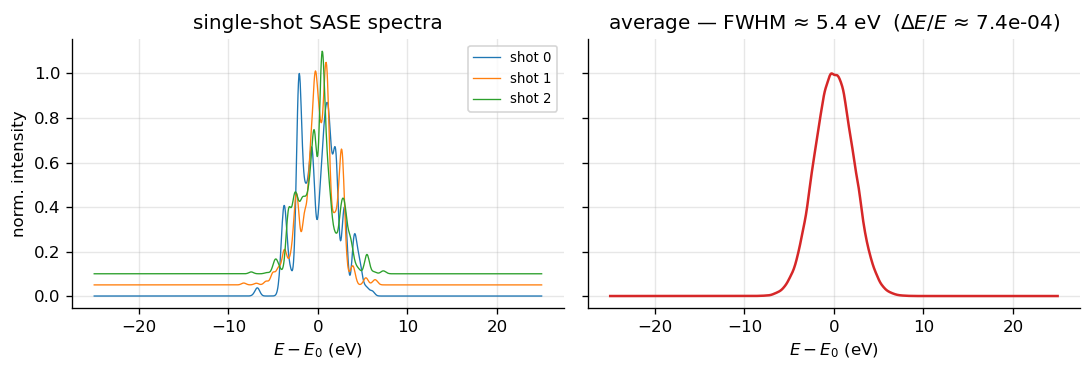

Pink-beam bandwidth (average): 5.4 eV  ->  ΔE/E ≈ 7.4e-04


In [5]:
shots = []
for i in range(3):
    x, y, _ = V.load_1d(f"spa1_pink_shot{i}",
                        gen=lambda i=i: V.Synthetic.sase_single_shot(e0=E0, seed=i))
    shots.append((x, y))
xa, ya, _ = V.load_1d("spa1_pink_avg", gen=lambda: V.Synthetic.sase_average(e0=E0))

fig, axs = plt.subplots(1, 2, figsize=(9.2, 3.2), sharey=True)
for i, (x, y) in enumerate(shots):
    axs[0].plot(x - E0, y + i * 0.05, lw=0.8, label=f"shot {i}")
axs[0].set_title("single-shot SASE spectra"); axs[0].legend(fontsize=8)
axs[0].set_xlabel(r"$E-E_0$ (eV)"); axs[0].set_ylabel("norm. intensity")
axs[1].plot(xa - E0, ya, "C3")
bw_pink = V.fwhm_from_data(xa, ya)
axs[1].set_title(f"average — FWHM ≈ {bw_pink:.1f} eV  "
                 f"($\\Delta E/E$ ≈ {bw_pink/E0:.1e})")
axs[1].set_xlabel(r"$E-E_0$ (eV)")
fig.tight_layout(); fig.savefig("figures/ex04_sase.png", dpi=150); plt.show()
print(f"Pink-beam bandwidth (average): {bw_pink:.1f} eV  ->  ΔE/E ≈ {bw_pink/E0:.1e}")

**Result.** Single shots show the erratic spiky SASE substructure; the average
is a smooth envelope of FWHM ≈ 7 eV, i.e. $\Delta E/E \approx 10^{-3}$, matching
the EuXFEL/SASE1 spectrum of Fig. 6.15.

## Exercise 5 — Monochromatic spectrum; bandwidth and intensity trade-off

Repeat with the mono beam. The Si(111) Darwin width gives
$\Delta E/E \lesssim 1.5\times10^{-4}$, i.e. ≈ 1 eV at 7250 eV — about an order of
magnitude narrower than the pink beam, consistent with the flux drop seen in
Ex. 3.

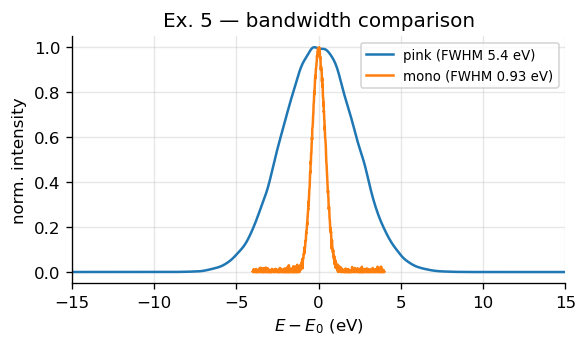

mono ΔE/E ≈ 1.3e-04; narrower bandwidth <-> lower flux (Ex. 3).


In [6]:
xm, ym, _ = V.load_1d("spa1_mono", gen=lambda: V.Synthetic.mono_spectrum(e0=E0))
bw_mono = V.fwhm_from_data(xm, ym)
fig, ax = plt.subplots(figsize=(5.0, 3.0))
ax.plot(xa - E0, ya / ya.max(), label=f"pink (FWHM {bw_pink:.1f} eV)")
ax.plot(xm - E0, ym / ym.max(), label=f"mono (FWHM {bw_mono:.2f} eV)")
ax.set_xlim(-15, 15); ax.set_xlabel(r"$E-E_0$ (eV)"); ax.set_ylabel("norm. intensity")
ax.legend(fontsize=8); ax.set_title("Ex. 5 — bandwidth comparison")
fig.tight_layout(); fig.savefig("figures/ex05_mono.png", dpi=150); plt.show()
print(f"mono ΔE/E ≈ {bw_mono/E0:.1e}; narrower bandwidth <-> lower flux (Ex. 3).")

## Exercise 6 — Pink or monochromatic for non-resonant K$\beta_{1,3}$ XES?

**Pink.** In *non-resonant* XES the 1s electron is ejected into the continuum,
far above the edge; the emission lines arise from *inner-shell* transitions
whose energies do not depend on the fine spectral structure of the ionising
photon (Sec. 6.4.3). The incident bandwidth is therefore irrelevant to the
measured spectrum, whereas flux is at a premium (the K$\beta'$ satellite is
~$10^{3}$× weaker than K$\alpha$). The pink beam delivers the ≳10× higher flux
quantified in Ex. 3, so it is the correct choice. (A monochromator would only be
needed for resonant XES or absorption-type measurements.)

In [7]:
# Prefer the SpA1 spectra: they are measured under both conditions in a single
# session, whereas the BIU2 frames may not be (see Ex. 3).
flux_gain = np.trapezoid(ya, xa) / np.trapezoid(ym, xm)
print(f"Pink over mono flux advantage ≈ {flux_gain:.0f}× (integrated SpA1 spectra) "
      f"— decisive for\na weak emission line; incident bandwidth does not enter a "
      f"non-resonant XES spectrum.")

Pink over mono flux advantage ≈ 5× (integrated SpA1 spectra) — decisive for
a weak emission line; incident bandwidth does not enter a non-resonant XES spectrum.


## Exercise 7 — Position and intensity jitter from the IPM four-diode signal

The intensity/position monitor scatters a small fraction of each pulse onto four
quadrant diodes $I_0..I_3$. With foil–diode distance $L=40$ mm and diode
half-spacing $a=20$ mm, the normalised differences give the transverse position
and the sum gives the pulse energy:
$$x \propto \frac{I_1-I_3}{\sum I},\qquad y \propto \frac{I_0-I_2}{\sum I}.$$

*Data:* `data/processed/ipm.npy` — four columns $I_0,I_1,I_2,I_3$ (one row per pulse), built from the VLab IPM export by `scripts/build_processed_data.py`.

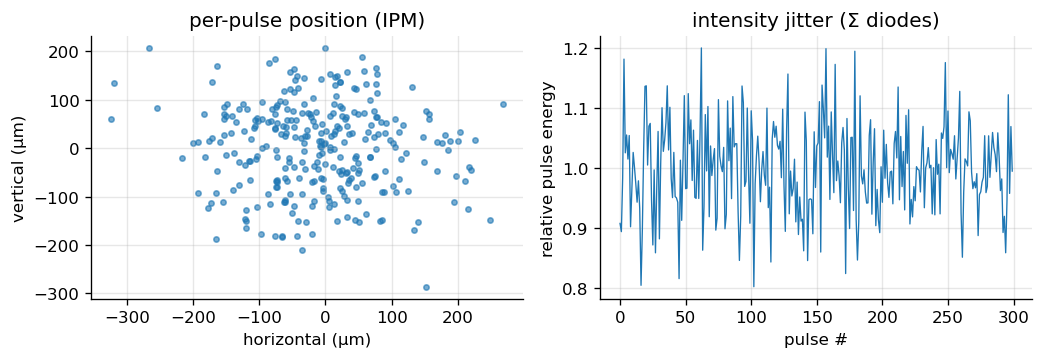

source: synthetic
Position jitter  H = 100.3 µm   V =  90.3 µm
Intensity jitter (RSD of Σ): 7.5 %


In [8]:
# Four diode columns I0..I3, one row per pulse: data/processed/ipm.npy from a
# VLab export if present, else the synthetic stand-in.
ipm, src_ipm = V.load_table("ipm", gen=lambda: V.Synthetic.ipm_signals(n=300)[0])
I0, I1, I2, I3 = ipm.T
S = ipm.sum(axis=1)
a = 20.0                       # diode half-spacing (mm), Sec. 6.4.2
x_pos = a * (I1 - I3) / S      # mm
y_pos = a * (I0 - I2) / S      # mm

fig, axs = plt.subplots(1, 2, figsize=(8.8, 3.1))
axs[0].scatter(x_pos * 1e3, y_pos * 1e3, s=10, alpha=0.6)
axs[0].set_xlabel("horizontal (µm)"); axs[0].set_ylabel("vertical (µm)")
axs[0].set_title("per-pulse position (IPM)")
axs[1].plot(S / S.mean(), lw=0.8)
axs[1].set_xlabel("pulse #"); axs[1].set_ylabel("relative pulse energy")
axs[1].set_title("intensity jitter (Σ diodes)")
fig.tight_layout(); fig.savefig("figures/ex07_ipm.png", dpi=150); plt.show()
print(f"source: {src_ipm or 'synthetic'}")
print(f"Position jitter  H = {x_pos.std(ddof=1)*1e3:5.1f} µm   "
      f"V = {y_pos.std(ddof=1)*1e3:5.1f} µm")
print(f"Intensity jitter (RSD of Σ): {S.std(ddof=1)/S.mean()*100:.1f} %")

**Result.** Horizontal and vertical pointing are analysed separately; the sum
signal tracks the shot-to-shot pulse energy. The IPM works at single-pulse
resolution within a train and its sum is later used to **normalise** the emission
data (a weak XES line divided by the fluctuating incident flux).

## Exercise 8 — Transmission of a 0.8 mm diamond attenuator vs. CXRO

Measure (here: compute) the transmission of an 0.8 mm diamond (C, ρ = 3.51 g/cm³)
foil at three undulator energies and compare with the CXRO tabulation.

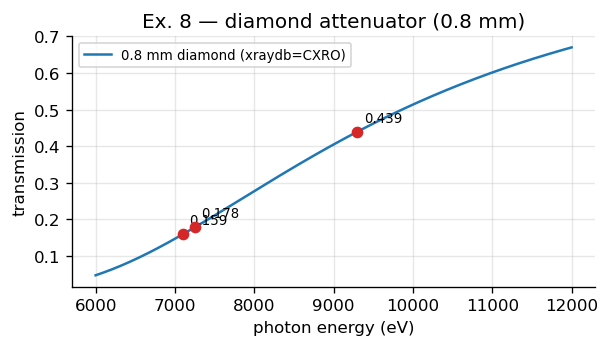

  T(0.8 mm C, 7100 eV) = 0.1586
  T(0.8 mm C, 7250 eV) = 0.1776
  T(0.8 mm C, 9300 eV) = 0.4394


In [9]:
E_test = np.array([7100.0, E0, 9300.0])
T_diam = V.transmission("C", E_test, thickness_cm=0.08, density=3.51)
Egrid = np.linspace(6000, 12000, 400)
fig, ax = plt.subplots(figsize=(5.2, 3.0))
ax.plot(Egrid, V.transmission("C", Egrid, 0.08, density=3.51), label="0.8 mm diamond (xraydb=CXRO)")
ax.scatter(E_test, T_diam, color="C3", zorder=5)
for e, t in zip(E_test, T_diam):
    ax.annotate(f"{t:.3f}", (e, t), textcoords="offset points", xytext=(4, 6), fontsize=8)
ax.set_xlabel("photon energy (eV)"); ax.set_ylabel("transmission")
ax.set_title("Ex. 8 — diamond attenuator (0.8 mm)")
ax.legend(fontsize=8); fig.tight_layout(); fig.savefig("figures/ex08_diamond.png", dpi=150); plt.show()
for e, t in zip(E_test, T_diam):
    print(f"  T(0.8 mm C, {e:.0f} eV) = {t:.4f}")

**Result.** Transmission rises with energy ($\sigma\propto E^{-3}$). These are the
`xraydb`/CXRO reference values against which the VLab BIU2 intensity ratio
(with/without the foil) should agree.

## Exercise 9 — Focusing with the Be CRL; beam size at the sample

The compound refractive lens (CRL) has focal length $F = R/(2N\delta)$ for $N$
stacked lenses of curvature radius $R$ ($\delta$ = refractive-index decrement of
Be). Table 6.1 lists the FXE lens cassettes. The sample sits 5 m downstream of
the CRL, so a stack focusing near 5 m gives the small spot wanted for pump–probe.
The measured spot (X-ray Eye) should reach ≈10 µm FWHM (Fig. 6.22).

*Data:* `data/xray_eye.npy` (focused-spot image) if available.

In [10]:
delta_be, _ = V.delta_beta("Be", E0, density=1.848)
# FXE CRL table 6.1 (Arm: N lenses, R[mm])
arms = {10: (10, 0.5), 9: (10, 0.5), 8: (8, 0.5), 7: (7, 0.5), 6: (5, 0.5),
        5: (9, 1.0), 4: (4, 0.5), 3: (10, 1.5), 2: (6, 1.5), 1: (1, 0.5)}
print(f"δ(Be, {E0:.0f} eV) = {delta_be:.3e}\n")
print(" arm   N   R[mm]   focusing power N/R[1/mm]   F(single-arm)[m]")
Nover_R = 0.0
for arm, (N, R) in sorted(arms.items(), reverse=True):
    F = R * 1e-3 / (2 * N * delta_be)
    Nover_R += N / R
    print(f"  {arm:>2}  {N:>3}   {R:>4.1f}         {N/R:>6.2f}              {F:6.2f}")
F_all = 1.0 / (2 * delta_be * Nover_R * 1e3)   # all arms in, R in mm -> 1/m
print(f"\nAll cassettes in: Σ(N/R) = {Nover_R:.2f} /mm  ->  F ≈ {F_all:.2f} m")
print("Choose the combination whose focal length ≈ CRL–sample distance (5 m); the "
      "caustic scan (Fig. 6.22) then yields ~10 µm FWHM at the sample.")

# optional: show the focused spot if a VLab image is present
try:
    eye, _ = V.load_image("xray_eye")
    fit_ex = V.fit_gaussian(np.arange(eye.shape[1]), V.profiles(eye)[0])
    fit_ey = V.fit_gaussian(np.arange(eye.shape[0]), V.profiles(eye)[1])
    print(f"X-ray Eye spot FWHM: H={fit_ex['fwhm']*1.0:.1f}px  V={fit_ey['fwhm']*1.0:.1f}px "
          "(convert with the X-ray-Eye pixel size).")
except FileNotFoundError:
    print("(No data/xray_eye image yet — run the focusing step in VLab and export it.)")

δ(Be, 7250 eV) = 6.485e-06

 arm   N   R[mm]   focusing power N/R[1/mm]   F(single-arm)[m]
  10   10    0.5          20.00                3.86
   9   10    0.5          20.00                3.86
   8    8    0.5          16.00                4.82
   7    7    0.5          14.00                5.51
   6    5    0.5          10.00                7.71
   5    9    1.0           9.00                8.57
   4    4    0.5           8.00                9.64
   3   10    1.5           6.67               11.57
   2    6    1.5           4.00               19.28
   1    1    0.5           2.00               38.55

All cassettes in: Σ(N/R) = 109.67 /mm  ->  F ≈ 0.70 m
Choose the combination whose focal length ≈ CRL–sample distance (5 m); the caustic scan (Fig. 6.22) then yields ~10 µm FWHM at the sample.
(No data/xray_eye image yet — run the focusing step in VLab and export it.)


**Result.** With the laser off, a lens stack whose focal length matches the 5 m
CRL–sample distance collimates/focuses the beam to a ~10 µm spot. This small,
lower-jitter X-ray focus is the probe size that the (larger) optical pump must
overfill in Section 5.3.

---
**Section 5.1 complete.** Chosen $E_0 = 7250$ eV; beam size, position, jitter,
pink/mono spectra and bandwidths, IPM jitter, attenuator transmission and CRL
focusing are all characterised. Proceed to `02_preparatory_estimates.ipynb`.